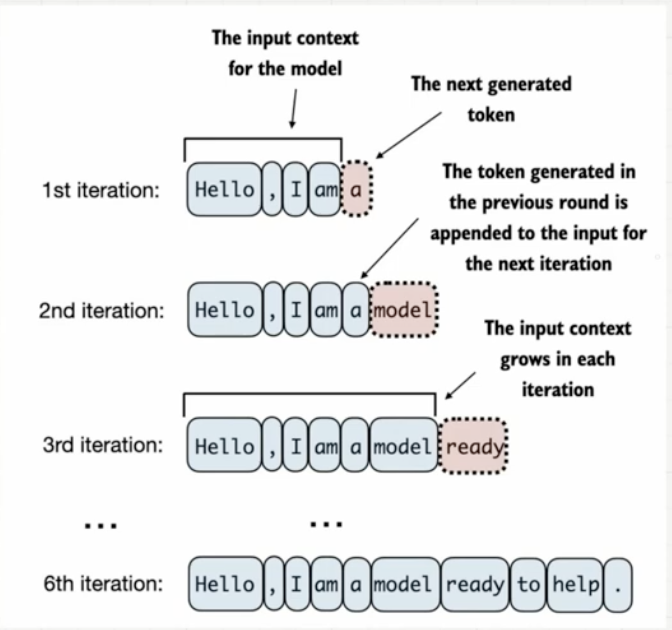

## Final output from gpt2 model is of size ```batch_size * num_tokens * vocab_size```

Consider example sentence "Every effort moves you"

1. Suppose if each word is atoken then there are 4 tokens

2. output we get is a 

Token1  ------------------- (vocab_size)

Token2  ------------------- (vocab_size)

Token3  ------------------- (vocab_size)

Token4  ------------------- (vocab_size)

That is num_tokens * vocab_size

3. Here 4 next word predictions are happening - 

```
Every - 
Every effort - 
Every effort moves - 
Every effort moves you - 
```

4. for each prediction task, we get a probability distribution for the next word among vocab_size

## Converting logits to token

1. Extract the last vector for every example in batch
2. If we observe, these logits donot add upto 1
3. Now using softmax, we convert these logits into probabilities
4. identify the index with the largest value and get that tokenid
5. append the tokenid to the previous inputs for the next round

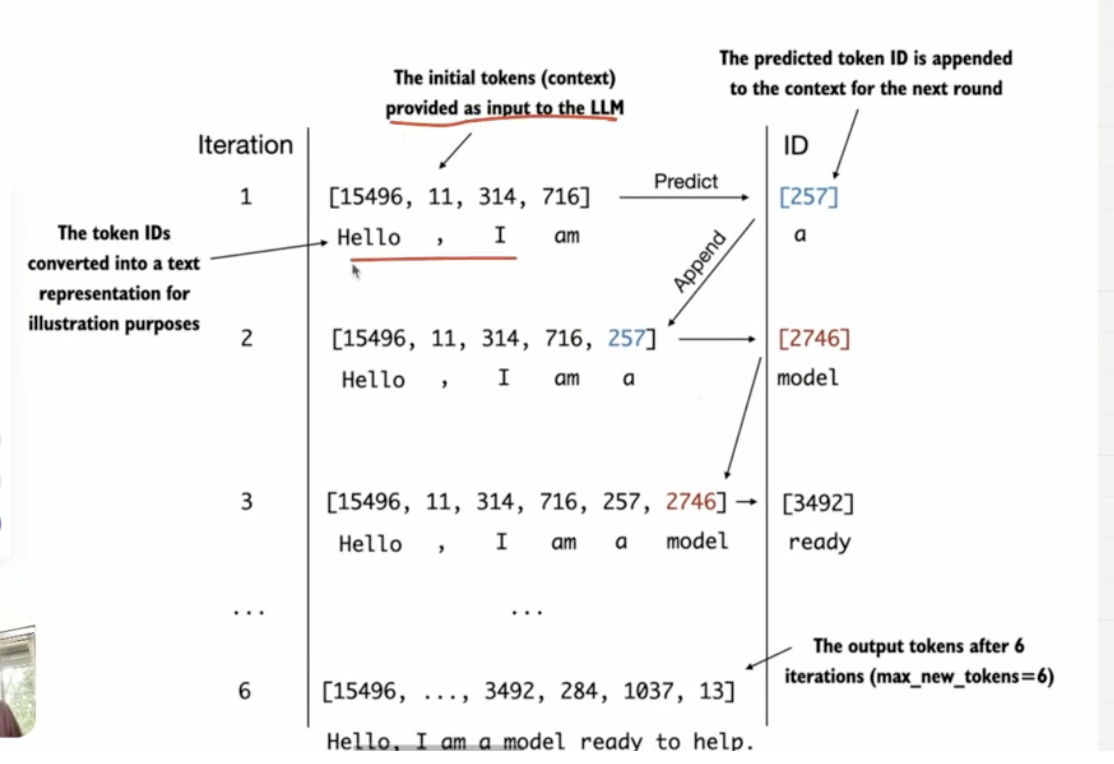

## Note -

1. This text generation takes place until max_new_tokens as specified by user

### Lets See it in Action 

In [10]:
import torch
import torch.nn as nn 

from types import SimpleNamespace
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "out_dim": 768,
    "n_heads": 12, ## Number of heads in a transformer
    "n_layers": 12, ## Number of transformer layers
    "drop_rate": 0.1,
    "qkv_bias": False
}


config = SimpleNamespace(**GPT_CONFIG_124M)
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1,keepdim=True, unbiased=False)
        norm_x = (x-mean)/ torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift


class MultiHeadAttention(nn.Module):
    """
    Analyzes relationship between input elements 
    """
    def __init__(self,cfg):
        super().__init__()
        
        self.out_dim = cfg.out_dim
        self.num_heads = cfg.n_heads
        self.per_head_out_dim = self.out_dim//self.num_heads

    
        self.query_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)
        self.key_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)
        self.value_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)

        self.drop_out = nn.Dropout(cfg.drop_rate)
        self.register_buffer("mask",
            torch.triu(torch.ones(cfg.context_length,cfg.context_length),diagonal=1)
        )

        self.out_proj = nn.Linear(self.out_dim, self.out_dim)


    def forward(self,x):
        batch_size, num_input_tokens, emb_dim = x.shape
        
        ### Shape = batch_size * num_input_tokens * out_dim
        queries = self.query_matrix(x)
        keys = self.key_matrix(x)
        values = self.value_matrix(x)


        ### Attention needs to be applied head wise, so split into heads
        queries = queries.view(batch_size, num_input_tokens, self.num_heads, self.per_head_out_dim)
        keys = keys.view(batch_size, num_input_tokens, self.num_heads, self.per_head_out_dim)
        values = values.view(batch_size, num_input_tokens, self.num_heads, self.per_head_out_dim)

        ### Apply transpose to push num_input_tokens , per_head_out to end
        queries = queries.transpose(1,2)
        keys = keys.transpose(1,2)
        values = values.transpose(1,2)

        ### Compute Attention
        #1. Attention Scores
        attn_scores = queries @ keys.transpose(2,3)

        #2. Masking
        mask_bool = self.mask.bool()[:num_input_tokens,:num_input_tokens]
        attn_scores.masked_fill_(mask_bool,-torch.inf)

        #3. Attention Weights
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim=-1)

        #4. Dropout
        attn_weights=self.drop_out(attn_weights)

        #5. Context Vector
        context_vec = (attn_weights @ values).transpose(1,2)

        #6. Reshape Context Vector back
        context_vec=context_vec.contiguous().view(batch_size,num_input_tokens,self.out_dim)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec



class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (

            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0/torch.pi)) * 
                (x+0.044715 * torch.pow(x,3))
            )
        )

class FeedForwardNN(nn.Module):
    """
    Handles each token independently unlike attention
    """
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg.emb_dim, 4*cfg.emb_dim), ## Expansion
            GELU(),
            nn.Linear(4*cfg.emb_dim,cfg.emb_dim),  ## Contraction
        )
    
    def forward(self,x):
        return self.layers(x)


class Transformer(nn.Module):
    def __init__(self,cfg):
        super().__init__()

        ## Layer Normalization
        # These are called pre-LayerNorm layers as they are applied before attention and feedforward pass
        # Older version used to have pro_LayerNorm but that is found to have wrose training dynamics
        self.layer_norm1 = LayerNorm(cfg.emb_dim)
        self.layer_norm2 = LayerNorm(cfg.emb_dim)

        ## Mulit Head Attention
        self.multi_head_attention = MultiHeadAttention(cfg)

        ## FeedForward Neural Network
        self.feed_forward_nn = FeedForwardNN(cfg) 

        ## Dropout 
        self.drop_shortcut = nn.Dropout(cfg.drop_rate)
    

    def forward(self,x):

        # Shortcut connection for attention block
        shortcut = x
        x = self.layer_norm1(x)
        x = self.multi_head_attention(x) # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x= x+shortcut # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.layer_norm2(x)
        x = self.feed_forward_nn(x)
        x = self.drop_shortcut(x)
        x = x+shortcut # Add the original input back

        return x

class GPT2(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(
            cfg.vocab_size,cfg.emb_dim
        )

        self.pos_emb = nn.Embedding(
            cfg.context_length,cfg.emb_dim
        )

        self.drop_emb = nn.Dropout(cfg.drop_rate)

        self.trf_blocks = nn.Sequential(
            *[Transformer(cfg) for _ in range(cfg.n_layers)]
        )

        self.final_norm = LayerNorm(cfg.emb_dim)
        self.out_head = nn.Linear(
            cfg.emb_dim,cfg.vocab_size,bias = False
        )


    def forward(self,x):
        batch_size,seq_len = x.shape
        
        ### Embeddings
        embeddings = self.tok_emb(x)
        pos_embeddings = self.pos_emb(torch.arange(seq_len,device = x.device))

        final_input_embeddings = embeddings + pos_embeddings


        ### Dropout
        # - Randomly turnoff input embeddings to 0
        # prevents overfitting
        x = self.drop_emb(final_input_embeddings)


        ### Transformer
        x = self.trf_blocks(x)

        ## Layer Normalization
        x = self.final_norm(x)

        ## getting logits out of the model
        ## siz eof this is num_tokens * vocab_size
        logits = self.out_head(x)

        return logits


In [11]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

## Tokenization

In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) #A
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


## Model pass

<div class="alert alert-block alert-info">

We disable dropout since we are not training the model. we put the model into .eval() mode, which disables random components like
dropout, which are only used during training
</div>

In [14]:
model = GPT2(config)
model.eval() #A
out = generate_text_simple(
model=model,
idx=encoded_tensor,
max_new_tokens=6,
context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 18390, 15761, 23650, 49737, 18992, 39878]])
Output length: 10


In [15]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am hike 1945mbolhler improperLER
